# Airbridges

Airbridges are ground-plane crossovers that hop *over* a CPW trace to tie
the ground plane together and suppress unwanted slotline modes. In Quantum
Metal an airbridge is a first-class `QComponent`: its geometry lives in the
design, so it shows up in `qm.view` and is exported by every renderer — no
GDS-only special case.

This tutorial covers the `Airbridge` component, automatic placement along a
routed CPW with `route_airbridges`, and GDS export.

## Setup

In [1]:
import qiskit_metal as qm
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.airbridge import Airbridge, route_airbridges

## Preview

Here is where we are headed: a meander CPW with airbridges auto-placed along
every straight **and** every bend. The rest of the tutorial builds up to this
one piece at a time.

05:41AM 03s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


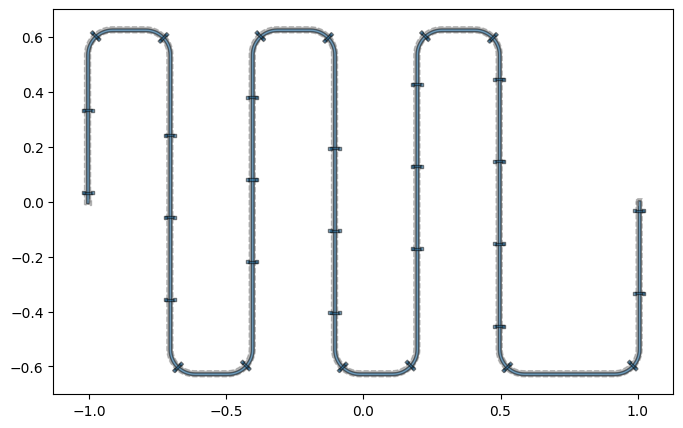

In [2]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

OpenToGround(design, "A", options=dict(pos_x="-1mm", orientation="0"))
OpenToGround(design, "B", options=dict(pos_x="1mm", orientation="180"))
cpw = RouteMeander(
    design,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        total_length="9mm",
        fillet="90um",
        trace_width="10um",
        trace_gap="6um",
        meander=Dict(spacing="0.3mm"),
    ),
)
design.rebuild()

route_airbridges(design, cpw, pitch="0.3mm", min_spacing="30um", bridge_at_corners=True)
design.rebuild()
qm.view(design)

## A single airbridge

The `Airbridge` component draws two base-metal landing pads joined by an
elevated bridge span. The bridge and the pads are emitted on separate layers
(`bridge_layer` / `pad_layer`) so the two-step fabrication is representable.

05:41AM 04s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


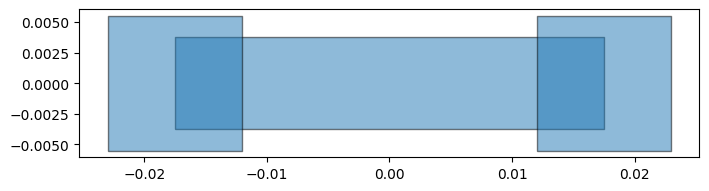

In [3]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

Airbridge(design, "ab", options=dict(crossover_length="24um"))
design.rebuild()
qm.view(design)

Key options (all parseable strings, e.g. `'22um'`):

- `crossover_length` — the gap the bridge spans, foot-to-foot. Size it to
  about `cpw_width + 2*cpw_gap` of the CPW you are crossing.
- `bridge_width` — width of the elevated span.
- `pad_width`, `pad_length` — the base landing-pad footprint.
- `bridge_layer`, `pad_layer` — the fabrication layers.

## Auto-placing airbridges along a CPW

`route_airbridges(design, route, ...)` adds `Airbridge` components along a
routed CPW. Placement follows the route's *filleted* centerline (the geometry
that is actually rendered), so every bridge sits on the trace and crosses it
perpendicular to the local direction — through bends as well as straights.
Bridges are spaced by `pitch` and kept `min_spacing` clear of the end pins.
By default each span is sized to the route's `trace_width + 2*trace_gap`.

05:41AM 04s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


...

05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 27 airbridges


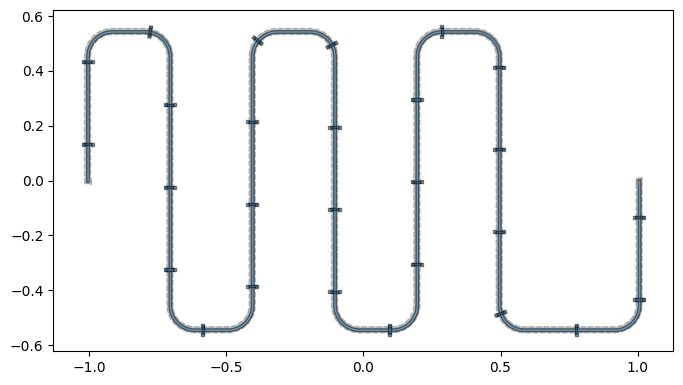

In [4]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

OpenToGround(design, "A", options=dict(pos_x="-1mm", orientation="0"))
OpenToGround(design, "B", options=dict(pos_x="1mm", orientation="180"))

cpw = RouteMeander(
    design,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        total_length="8mm",
        fillet="90um",
        trace_width="10um",
        trace_gap="6um",
        meander=Dict(spacing="0.3mm"),
    ),
)
design.rebuild()

bridges = route_airbridges(design, cpw, pitch="0.3mm", min_spacing="30um")
design.rebuild()
print(f"placed {len(bridges)} airbridges")
qm.view(design)

`route_airbridges` is idempotent: re-running it (e.g. re-executing this cell,
or after re-routing) clears the airbridges it previously placed under the same
`name` and re-places them. Tune the spacing, or forward extra options to every
bridge via `ab_options`:

05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 17 airbridges


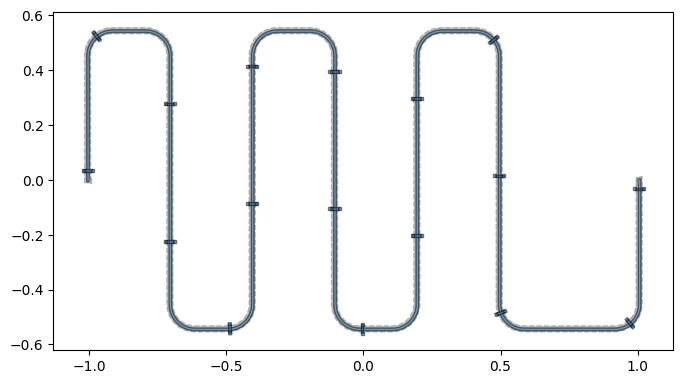

In [5]:
bridges = route_airbridges(
    design, cpw, pitch="0.5mm", min_spacing="30um", ab_options=dict(bridge_width="10um")
)
design.rebuild()
print(f"placed {len(bridges)} airbridges")
qm.view(design)

### Guaranteeing a bridge on every bend

Uniform spacing already covers bends wherever a `pitch` sample happens to land
on a fillet arc, but with a coarse `pitch` a corner can fall between samples.
Set `bridge_at_corners=True` to force one bridge centered on every rounded
bend, in addition to the uniform-pitch bridges. A uniform bridge that would
land within half a pitch of a corner bridge is dropped so the two do not bunch
up.

05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 18 airbridges (one on every bend)


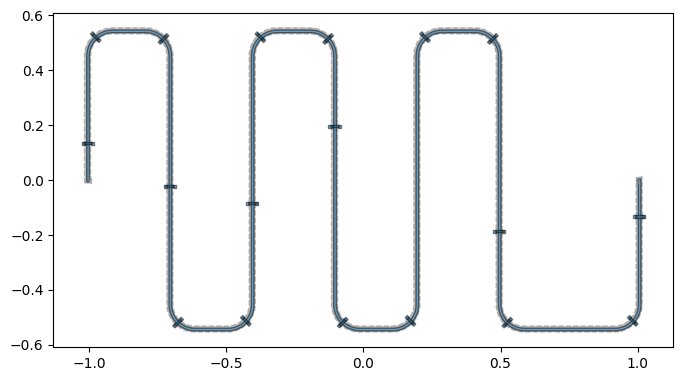

In [6]:
bridges = route_airbridges(
    design, cpw, pitch="0.6mm", min_spacing="30um", bridge_at_corners=True
)
design.rebuild()
print(f"placed {len(bridges)} airbridges (one on every bend)")
qm.view(design)

## Export to GDS

Because airbridges are real components, they export like anything else — the
bridge and pad polygons land on their configured GDS layers. Here we export a
straight CPW with airbridges:

In [7]:
import tempfile
import os

gdesign = designs.DesignPlanar()
gdesign.overwrite_enabled = True
OpenToGround(gdesign, "A", options=dict(pos_x="-0.6mm", orientation="0"))
OpenToGround(gdesign, "B", options=dict(pos_x="0.6mm", orientation="180"))
gcpw = RouteStraight(
    gdesign,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        trace_width="10um",
        trace_gap="6um",
    ),
)
gdesign.rebuild()
route_airbridges(gdesign, gcpw, pitch="0.2mm", min_spacing="30um")
gdesign.rebuild()

path = os.path.join(tempfile.mkdtemp(), "airbridge_demo.gds")
gdesign.renderers.gds.export_to_gds(path)
print("wrote", path)

05:41AM 06s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/home/user/qiskit-metal/tutorials/2 From components to chip/resources".


05:41AM 06s WARNING [_check_either_cheese]: layer=30 is not in chip=main either in no_cheese_view_in_file or cheese_view_in_file from self.options.


05:41AM 06s WARNING [_check_either_cheese]: layer=31 is not in chip=main either in no_cheese_view_in_file or cheese_view_in_file from self.options.


wrote /tmp/tmp963uolnm/airbridge_demo.gds


### Viewing the exported GDS

Let's load the file back with `gdstk` and draw it. The airbridge span and pads
are read straight from the GDS layers; the CPW ground/trace/gap is
reconstructed from the design's own clearance geometry, because a fabrication
ground plane is a solid metal pour — a flat fill of the raw GDS would hide the
thin CPW gap. Layers are colored with a legend.

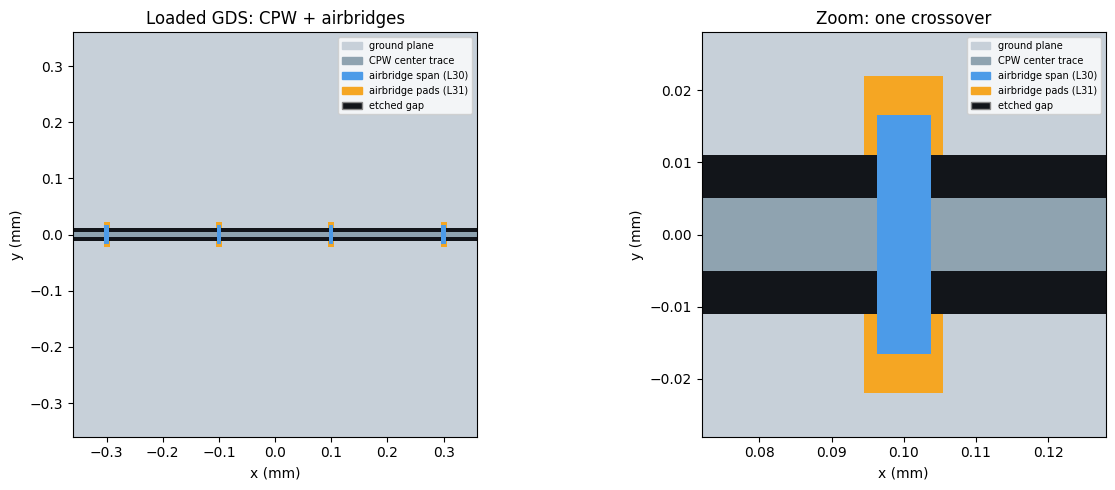

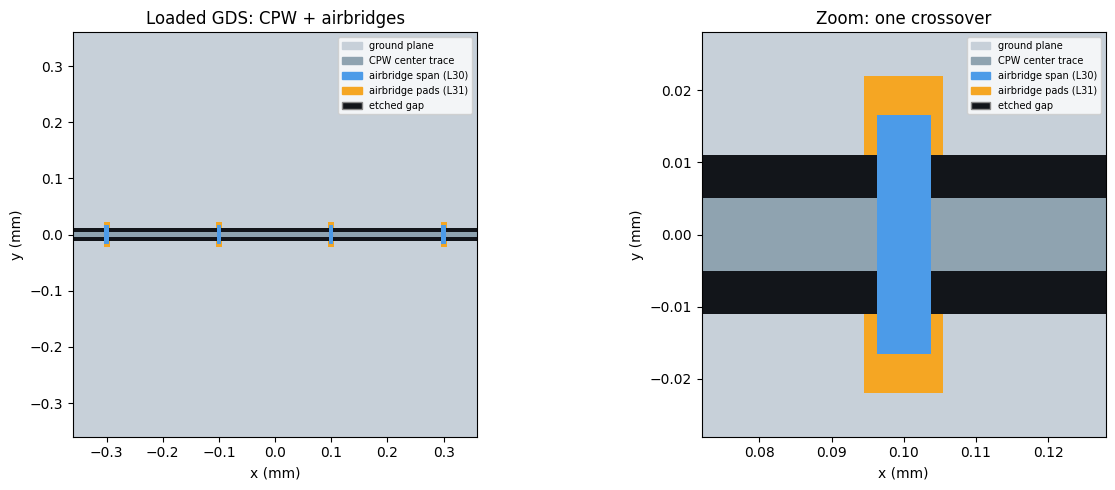

In [8]:
import gdstk
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch
from shapely.geometry import Polygon as SPoly, box
from shapely.ops import unary_union


def show_airbridge_gds(
    design, gds_path, center_mm, span_mm, ax, bridge_layer=30, pad_layer=31
):
    """Load an exported GDS and draw it CPW-correctly, colored + legend.

    Airbridge polygons come straight from the loaded GDS (``bridge_layer`` /
    ``pad_layer``); the CPW ground/trace/gap is reconstructed from the design's
    ``subtract`` QGeometry so the thin gap is visible against the solid ground.
    """
    lib = gdstk.read_gds(gds_path)
    top = next((c for c in lib.cells if c.name == "TOP"), lib.cells[0])

    def gds_union(layer):
        ps = [
            SPoly(p.points).buffer(0)
            for p in top.get_polygons(depth=None)
            if p.layer == layer
        ]
        return unary_union(ps) if ps else None

    def buf(row):
        g = row.geometry
        if row.get("width", 0) and g.geom_type in ("LineString", "MultiLineString"):
            return g.buffer(
                design.parse_value(row.width) / 2.0, cap_style=2, join_style=2
            )
        return g

    sx = design.parse_value(design.chips.main.size.size_x)
    sy = design.parse_value(design.chips.main.size.size_y)
    pt, po = design.qgeometry.tables["path"], design.qgeometry.tables["poly"]
    gaps = unary_union(
        [buf(r) for _, r in pt.iterrows() if r["subtract"]]
        + [buf(r) for _, r in po.iterrows() if r["subtract"]]
    )
    metal = box(-sx / 2, -sy / 2, sx / 2, sy / 2).difference(gaps)
    trace = unary_union([buf(r) for _, r in pt.iterrows() if not r["subtract"]])
    bridge, pads = gds_union(bridge_layer), gds_union(pad_layer)

    def draw(geom, color):
        if geom is None or geom.is_empty:
            return
        for g in [geom] if geom.geom_type == "Polygon" else geom.geoms:
            v = list(g.exterior.coords)
            c = [Path.MOVETO] + [Path.LINETO] * (len(v) - 2) + [Path.CLOSEPOLY]
            for r in g.interiors:
                rv = list(r.coords)
                v += rv
                c += [Path.MOVETO] + [Path.LINETO] * (len(rv) - 2) + [Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(v, c), facecolor=color, edgecolor="none"))

    ground, tr, br, pa, sub = "#C7D0D9", "#8FA3B0", "#4C9BE8", "#F5A623", "#12151a"
    ax.set_facecolor(sub)
    for geom, col in [(metal, ground), (trace, tr), (pads, pa), (bridge, br)]:
        draw(geom, col)
    cx, cy = center_mm
    ax.set_xlim(cx - span_mm, cx + span_mm)
    ax.set_ylim(cy - span_mm, cy + span_mm)
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.legend(
        handles=[
            Patch(color=ground, label="ground plane"),
            Patch(color=tr, label="CPW center trace"),
            Patch(color=br, label=f"airbridge span (L{bridge_layer})"),
            Patch(color=pa, label=f"airbridge pads (L{pad_layer})"),
            Patch(facecolor=sub, edgecolor="#888", label="etched gap"),
        ],
        fontsize=7,
        loc="upper right",
    )
    return lib


# Center the zoom on one of the placed airbridges.
ab_x = sorted(
    gdesign.parse_value(c.options["pos_x"])
    for n, c in gdesign.components.items()
    if n.startswith("cpw_ab_")
)
zoom_x = ab_x[len(ab_x) // 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show_airbridge_gds(gdesign, path, center_mm=(0.0, 0.0), span_mm=0.36, ax=axes[0])
axes[0].set_title("Loaded GDS: CPW + airbridges")
show_airbridge_gds(gdesign, path, center_mm=(zoom_x, 0.0), span_mm=0.028, ax=axes[1])
axes[1].set_title("Zoom: one crossover")
fig.tight_layout()
fig

## Experimental: 3D airbridges

In a planar view and in GDS the crossover is flat (z = 0). For 3D FEM the
span should be *elevated* above the base metal. Metal's 3D renderers extrude
each layer by the `thickness` / `z_coord` in the design's **layer stack**, so
lifting the `bridge_layer` is all it takes — the same rows feed gmsh, and (as
the ecosystem matures) AWS Palace or Ansys.

To keep the elevated span connected to the base metal (so the design meshes as
one conductor rather than a floating bar), the airbridges also grow **support
posts** that rise from the pads to the span — enabled with `enable_posts`, and
given a height by the matching layer-stack row:

```python
from qiskit_metal.qlibrary.tlines.airbridge import (
    route_airbridges,
    apply_airbridge_layer_stack,
)

# design must be a DesignMultiPlanar (it carries a layer stack)
route_airbridges(design, cpw, pitch="0.3mm", enable_posts=True)
apply_airbridge_layer_stack(design, bridge_z_coord="3um", include_posts=True)
# then render 3D with the airbridge layers marked metal, e.g.
#   QGmshRenderer(design, layer_types=dict(metal=[1, 30, 31, 32], dielectric=[3]))
```

The schematic below (drawn to scale) shows the resulting shape: the elevated
span on two posts, hopping over the CPW.

### Validating on the open FEM path (Elmer)

Because the airbridge is now a connected 3D solid, it goes straight into the
open-source FEM path — no Ansys required. `QElmerRenderer` meshes it (via gmsh)
and runs a capacitance solve:

```python
from qiskit_metal.renderers.renderer_elmer.elmer_renderer import QElmerRenderer

er = QElmerRenderer(design, layer_types=dict(metal=[1, 30, 31, 32], dielectric=[3]))
er.gmsh.options.mesh.min_size = "5um"
er.gmsh.options.mesh.max_size = "60um"
er.render_design(open_pins=[("A", "open"), ("B", "open")], skip_junctions=True)
er.add_solution_setup("capacitance")
er.run("capacitance")        # needs the ElmerSolver binary
er.capacitance_matrix
```

The mesh and the Elmer `.sif` solver input are produced with only the
pip-installable `gmsh`; the final `run(...)` needs the **ElmerSolver** binary,
which you install from your OS package manager / the Elmer PPA (it is not a
Python package, so `pip install quantum-metal[fem]` does not bring it in).
`tests/test_airbridge_elmer.py` runs this end-to-end where a solver is present
and skips otherwise.

> ⚠️ **Experimental.** The design meshes as a connected 3D solid and produces a
> valid Elmer solver input, but the numerical solve isn't run in CI (no solver
> binary there), so the extracted values are not yet validated. Follow / help
> validate in
> [issue #1144](https://github.com/qiskit-community/qiskit-metal/issues/1144).

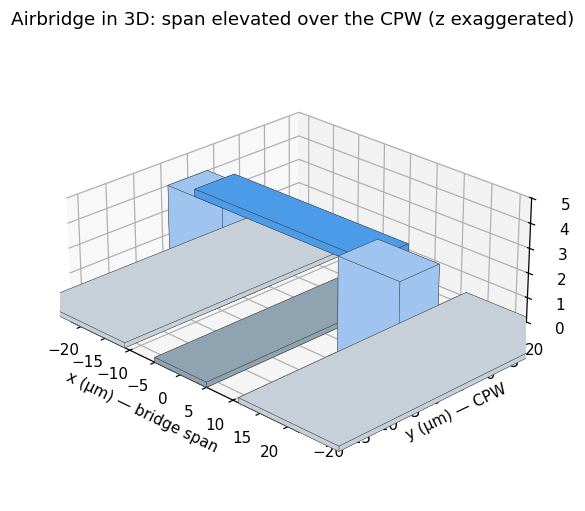

In [9]:
# 3D schematic of the airbridge. The in-plane (x, y) extents are read straight
# from the real Airbridge QGeometry + CPW params, so the span, posts and pads
# sit exactly where the component puts them — symmetric, with the span reaching
# the pad centres. The z axis is schematic: the true elevation (~3um) is
# invisible next to a ~40um span, so it is exaggerated here for legibility.
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from qiskit_metal.designs.design_multiplanar import MultiPlanar
from qiskit_metal.qlibrary.tlines.airbridge import Airbridge

# One airbridge with posts, at the origin. Native frame: the span crosses along
# x, so the CPW it hops runs along y.
_d = MultiPlanar()
_d.overwrite_enabled = True
_ab = Airbridge(_d, "ab", options=dict(enable_posts="True"))
_d.rebuild()
_p = _ab.parse_options()


def _box(x0, x1, y0, y1, z0, z1):
    c = np.array(
        [
            [x0, y0, z0],
            [x1, y0, z0],
            [x1, y1, z0],
            [x0, y1, z0],
            [x0, y0, z1],
            [x1, y0, z1],
            [x1, y1, z1],
            [x0, y1, z1],
        ]
    )
    f = [
        [0, 1, 2, 3],
        [4, 5, 6, 7],
        [0, 1, 5, 4],
        [2, 3, 7, 6],
        [1, 2, 6, 5],
        [0, 3, 7, 4],
    ]
    return [c[i] for i in f]


fig = plt.figure(figsize=(8, 5.5))
ax = fig.add_subplot(111, projection="3d")


def _add(polys, color, alpha=1.0):
    ax.add_collection3d(
        Poly3DCollection(
            polys, facecolor=color, edgecolor="#333", linewidths=0.25, alpha=alpha
        )
    )


Z_BASE, Z_SPAN = 0.2, 4.0  # schematic display bands (z is exaggerated)

# CPW cross-section, sized from the crossover the bridge actually spans.
_w = _d.parse_value("10um") * 1e3  # trace width (um)
_g = _d.parse_value("6um") * 1e3  # trace gap (um)
_Y = (2 * _p.pad_length + _p.crossover_length) * 1e3  # how far to run the CPW (um)
_add(_box(-_w / 2, _w / 2, -_Y / 2, _Y / 2, 0, Z_BASE), "#8FA3B0")  # center trace
_add(
    _box(_w / 2 + _g, _w / 2 + _g + 18, -_Y / 2, _Y / 2, 0, Z_BASE), "#C7D0D9"
)  # ground (far)
_add(
    _box(-(_w / 2 + _g + 18), -(_w / 2 + _g), -_Y / 2, _Y / 2, 0, Z_BASE), "#C7D0D9"
)  # ground (near)

# Airbridge parts: x/y bounds are the REAL geometry; z is the schematic band.
_bands = {
    31: (0, Z_BASE, "#F5A623"),  # landing pads (base metal)
    32: (Z_BASE, Z_SPAN, "#9EC4EF"),  # support posts (legs)
    30: (Z_SPAN, Z_SPAN + 0.3, "#4C9BE8"),
}  # elevated span
_ordr = {31: 0, 32: 1, 30: 2}
for _, _row in sorted(
    _ab.qgeometry_table("poly").iterrows(), key=lambda r: _ordr[int(r[1]["layer"])]
):
    _z0, _z1, _col = _bands[int(_row["layer"])]
    _x0, _y0, _x1, _y1 = (v * 1e3 for v in _row["geometry"].bounds)
    _add(_box(_x0, _x1, _y0, _y1, _z0, _z1), _col)

ax.set_xlim(-_Y / 2, _Y / 2)
ax.set_ylim(-_Y / 2, _Y / 2)
ax.set_zlim(0, Z_SPAN + 1)
ax.set_box_aspect((_Y, _Y, 0.42 * _Y))  # stretch z so the bridge stands up
ax.view_init(elev=25, azim=-45)  # both support legs visible
ax.set_xlabel("x (µm) — bridge span")
ax.set_ylabel("y (µm) — CPW")
ax.set_zlabel("z (schematic)")
ax.set_title("Airbridge in 3D: span elevated over the CPW (z exaggerated)")
fig

That's the airbridge workflow: place them (individually or automatically),
see them in `qm.view`, and export. Design-of-record and roadmap (including the
experimental 3D/Ansys span) are tracked in issue #1138.